# Data Quality Check

## Import Libraries

In [111]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

## Loading data

In [112]:
sales_train = pd.read_csv("E:/sales_predict/datasets/sales_train.csv")
items = pd.read_csv("E:/sales_predict/datasets/items.csv")
item_categories = pd.read_csv("E:/sales_predict/datasets/item_categories.csv")
shops = pd.read_csv("E:/sales_predict/datasets/shops.csv")
test = pd.read_csv("E:/sales_predict/datasets/test.csv")
sample_submission = pd.read_csv("E:/sales_predict/datasets/sample_submission.csv")

 ## Explore data

In [113]:
item_categories.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


In [114]:
sales_train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


In [115]:
items.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [116]:
sample_submission.head()

,ID,item_cnt_month
0,0,0.5
1,1,0.5
2,2,0.5
3,3,0.5
4,4,0.5


In [117]:
shops.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


In [118]:
test.head()

,ID,shop_id,item_id
0,0,5,5037
1,1,5,5320
2,2,5,5233
3,3,5,5232
4,4,5,5268


## Processing of identical stores

In [119]:
sales_train.loc[sales_train["shop_id"] == 0, "shop_id"] = 57
sales_train.loc[sales_train["shop_id"] == 1, "shop_id"] = 58
sales_train.loc[sales_train["shop_id"] == 10, "shop_id"] = 11
sales_train.loc[sales_train["shop_id"] == 39, "shop_id"] = 40

test.loc[test["shop_id"] == 0, "shop_id"] = 57
test.loc[test["shop_id"] == 1, "shop_id"] = 58
test.loc[test["shop_id"] == 10, "shop_id"] = 11
test.loc[test["shop_id"] == 39, "shop_id"] = 40

## Data merging

In [120]:
df = sales_train.merge(items, on='item_id', how='left')

In [121]:
df = df.merge(item_categories, on='item_category_id', how='left')

In [122]:
df = df.merge(shops, on='shop_id', how='left')

In [123]:
df.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
0,02.01.2013,0,59,22154,999.00,1.0,ЯВЛЕНИЕ 2012 (BD),37,Кино - Blu-Ray,"Ярославль ТЦ ""Альтаир"""
1,03.01.2013,0,25,2552,899.00,1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
2,05.01.2013,0,25,2552,899.00,-1.0,DEEP PURPLE The House Of Blue Light LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
3,06.01.2013,0,25,2554,1709.05,1.0,DEEP PURPLE Who Do You Think We Are LP,58,Музыка - Винил,"Москва ТРК ""Атриум"""
4,15.01.2013,0,25,2555,1099.00,1.0,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,Музыка - CD фирменного производства,"Москва ТРК ""Атриум"""


## Data conversion

In [124]:
print(df['date'].dtype)
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
print(df['date'].dtype)
df = df.sort_values('date').reset_index(drop=True)

object
datetime64[ns]


## Checking missing data

In [125]:
print(df.isna().sum())
missing_rows = df[df.isna().any(axis=1)]

date                  0
date_block_num        0
shop_id               0
item_id               0
item_price            0
item_cnt_day          0
item_name             0
item_category_id      0
item_category_name    0
shop_name             0
dtype: int64


## Duplicates

In [126]:
duplicates = df[df.duplicated()]
print("Дубликаты:", len(duplicates))

Дубликаты: 186


In [127]:
duplicates.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name
23142,2013-01-05,0,54,20130,149.0,1.0,УЧЕНИК ЧАРОДЕЯ (регион),40,Кино - DVD,"Химки ТЦ ""Мега"""
1441022,2014-02-23,13,50,3423,999.0,1.0,"Far Cry 3 (Classics) [Xbox 360, русская версия]",23,Игры - XBOX 360,"Тюмень ТЦ ""Гудвин"""
1461010,2014-03-01,14,40,4351,399.0,1.0,"LEGO Marvel Super Heroes [PC, Jewel, русские с...",30,Игры PC - Стандартные издания,"РостовНаДону ТРК ""Мегацентр Горизонт"" Островной"
1463172,2014-03-02,14,40,20606,799.0,1.0,Фигурка Minecraft Series 1 Creeper With Dynami...,72,Подарки - Фигурки,"РостовНаДону ТРК ""Мегацентр Горизонт"" Островной"
1464191,2014-03-02,14,40,9862,399.0,1.0,ВИЙ,40,Кино - DVD,"РостовНаДону ТРК ""Мегацентр Горизонт"" Островной"


### Summed up the sales of identical products in duplicates

In [128]:
df.loc[df.duplicated(), "item_cnt_day"] = df[df.duplicated()].groupby("item_id")["item_cnt_day"].sum()

 ### Checking for duplicates

In [129]:
duplicates = df[df.duplicated()]
print("Дубликаты:", len(duplicates))

Дубликаты: 0


## Checked the maximum and minimum time intervals

In [130]:
print(df['date'].min(), df['date'].max())

2013-01-01 00:00:00 2015-10-31 00:00:00


## Data Visualization

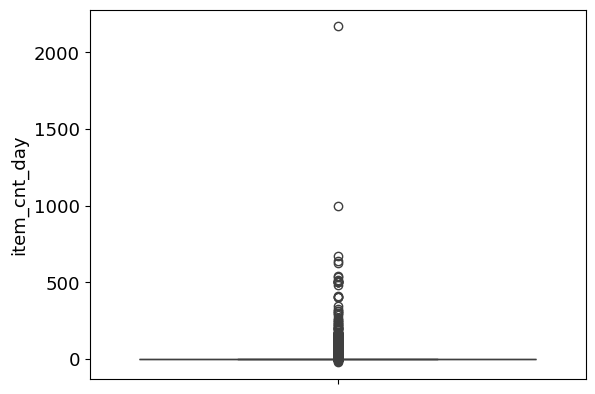

In [131]:
sns.boxplot(y = "item_cnt_day", data = df);

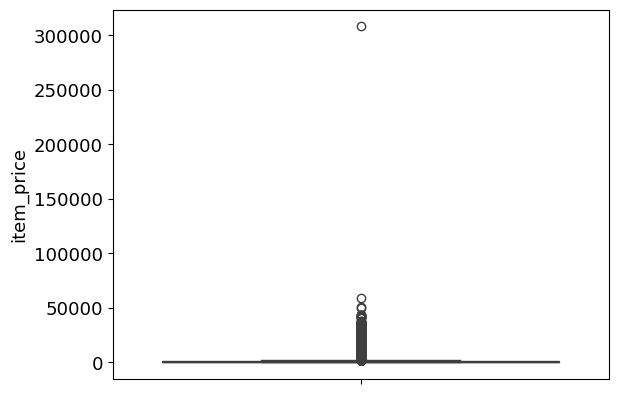

In [132]:
sns.boxplot(y = "item_price", data = df);

### Checked the outlier in item_price

In [141]:
df[df['item_price'] == df['item_price'].max()]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,returns
891801,2013-09-17,8,12,11365,50000.0,1.0,Доставка (EMS),9,Доставка товара,Интернет-магазин ЧС,0.0
1165576,2013-12-13,11,12,6066,50000.0,1.0,Radmin 3 - 522 лиц.,75,Программы - Для дома и офиса,Интернет-магазин ЧС,0.0
1514070,2014-03-20,14,25,13199,50000.0,1.0,Коллекционные шахматы (Властелин Колец),69,Подарки - Сувениры,"Москва ТРК ""Атриум""",0.0


In [134]:
df = df[df["item_price"] > 0]

In [135]:
df["item_price"] = df["item_price"].clip(upper=50000)

## Handle negative item_cnt_day feature

### Make returns feature

In [136]:
df['returns'] = np.where(df['item_cnt_day'] < 0, -df['item_cnt_day'], 0)
returns_df = df[df['returns'] > 0].copy()

### Explore negative item_cnt_day

<Axes: xlabel='item_price', ylabel='returns'>

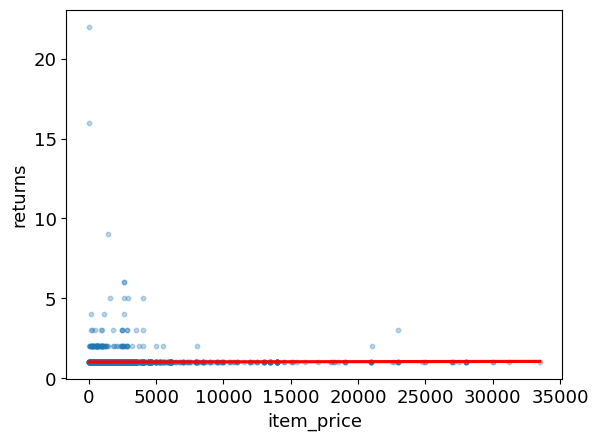

In [137]:
sns.regplot(
    x='item_price', 
    y='returns', 
    data=returns_df,
    scatter_kws={'alpha':0.3, 's':10},
    line_kws={'color':'red'}
)

From the graph it is clear that the lower the price, the higher the chance of a return, so it is quite logical to assume that a negative price is a return

### Checked max of returns

In [138]:
df[df['returns'] == df['returns'].max()]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,returns
1031583,2013-11-02,10,12,8023,15.0,-22.0,ZL004 Лазерные наклейки Смайлики маленькие,66,"Подарки - Открытки, наклейки",Интернет-магазин ЧС,22.0


## Checked df

In [139]:
df.head(30)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,returns
0,2013-01-01,0,18,5823,2500.0,1.0,Playstation Store пополнение бумажника: Карта ...,35,Карты оплаты - PSN,"Красноярск ТЦ ""Июнь""",0.0
1,2013-01-01,0,27,5573,849.0,1.0,PS Move Motion Controller Charger (Зарядная ст...,2,Аксессуары - PS3,"Москва ТЦ ""МЕГА Белая Дача II""",0.0
2,2013-01-01,0,7,1006,399.0,1.0,3D Crystal Puzzle Дельфин XL,67,Подарки - Развитие,"Воронеж ТРЦ ""Максимир""",0.0
3,2013-01-01,0,19,17707,899.0,1.0,Праздник спорта (Essentials) (только для PS Mo...,19,Игры - PS3,"Курск ТЦ ""Пушкинский""",0.0
4,2013-01-01,0,14,19548,149.0,1.0,ТАКИЕ РАЗНЫЕ БЛИЗНЕЦЫ (регион),40,Кино - DVD,"Казань ТЦ ""ПаркХаус"" II",0.0
5,2013-01-01,0,27,5574,699.0,2.0,PS Move Navigation Controller (Дополнительный ...,2,Аксессуары - PS3,"Москва ТЦ ""МЕГА Белая Дача II""",0.0
6,2013-01-01,0,8,16993,399.0,1.0,ПЕТЛЯ ВРЕМЕНИ,40,Кино - DVD,"Воронеж ТРЦ Сити-Парк ""Град""",0.0
7,2013-01-01,0,28,6468,449.0,1.0,"Sims 3 [PC, Jewel, русская версия]",30,Игры PC - Стандартные издания,"Москва ТЦ ""МЕГА Теплый Стан"" II",0.0
8,2013-01-01,0,19,13071,499.0,1.0,Кабель универсальный HDMI Artplays 2 м (ver. 1.4),3,Аксессуары - PS4,"Курск ТЦ ""Пушкинский""",0.0
9,2013-01-01,0,51,6450,483.0,1.0,Silent Hill Shattered Memories (Essentials) [P...,21,Игры - PSP,"Тюмень ТЦ ""Зеленый Берег""",0.0
